# The Multi-Needle Problem: Agentic Retrieval and Reasoning Fails to Scale

Reliable code generation requires AI agents that can accurately retrieve relevant information and reason over large corpora of text. But how well does agentic retrieval actually work — and where does it break down? We present results from a parametric experiment measuring the accuracy and completeness of an agentic retrieval system (Claude Sonnet 4.6, effort: low) across three task types of increasing complexity: **single-needle** lookup (find one fact), **multi-chain** retrieval (follow a chain of references across files), and **multi-reasoning** synthesis (locate scattered clues and integrate them to answer a question). Tasks are parametrised by corpus size (20k–800k tokens), number of items to find (2–16), and reference indirectness (exact keyword → synonym → contextual paraphrase), across two content domains: a Python repository and noir detective fiction.

The headline result: **single-fact retrieval works well (~90% accuracy), but performance degrades sharply with task complexity** — multi-chain retrieval drops to ~50%, and multi-reasoning to ~20%. The number of items to locate compounds the difficulty further. Content structure matters too: the agent performs markedly better on Python code than on narrative prose for multi-hop tasks, likely because code offers grep-friendly symbols and structured file paths. These results establish baseline performance curves for agentic retrieval and highlight where current capability is insufficient for reliable automation.

## Task Examples

The three experiment types represent increasing levels of retrieval and reasoning difficulty. Each task is posed to the agent as a question over a corpus of text files.

**Single needle** — locate one specific fact in the corpus:
> *"What is the value of `MAX_TASK_RETRY_DELAY` defined in this codebase?"* → **47**

> *"According to Deke the bartender's witness statement, what location did the older man whisper to the kid at The Crimson Door Lounge?"* → **The Starlight Motor Inn, room 14**

**Multi-chain** — follow a chain of cross-references across files to reach a final answer:
> *"In `api/pagination.py`, `BULK_REQUEST_LIMIT` is assigned the value of `BULK_FETCH_LIMIT` imported from `api/auth.py`. What is the value of `BULK_FETCH_LIMIT`?"* → **250**

> *"Starting from the matchbook Catherine left with Eleanor Walsh, follow the chain to Deke at The Crimson Door. What address is written on the envelope Deke has been holding?"* → **Warehouse 9, Pier 41, north dock**

**Multi-reasoning** — find scattered clues and synthesise them to answer a question:
> *"What distinctive physical mark on his left hand identified Catherine's secret boyfriend as the handler Silas Gregg?"* → requires locating two independent descriptions of a scar across the left knuckle — one from a landlady's statement, one from a detective debrief — and connecting them.

In [1]:
BATCH_NAME = "full-sweep__20260408T130426"
WORKSPACE_DIR = "../workspace"

In [2]:
from pathlib import Path
from agent_retrieval.analysis.loader import load_batch_results
df = load_batch_results(BATCH_NAME, Path(WORKSPACE_DIR))
print(f"Loaded {len(df)} verdicts across {df['experiment_id'].nunique()} parametrisations")
df.head()

Loaded 1074 verdicts across 335 parametrisations


,experiment_id,run_id,batch_name,weighted_score,total_context_tokens,total_turns,duration_seconds,total_cost_usd,content_profile,corpus_token_count,...,score_inference_from_context,score_multi_source_synthesis,score_identification_of_all_eight_items,score_correct_timeline_construction,score_understanding_of_compartmentalization,score_evidence_synthesis_across_sources,score_causal_reasoning_about_parallel_operations,score_integration_understanding,score_cross_file_reasoning,score_constraint_identification
0,multi_chain__noir_fiction__160k__easy__context...,053763251176,full-sweep__20260408T130426,0.0600,55797,3,0.0,0.096051,noir_fiction,160000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,multi_chain__noir_fiction__160k__easy__context...,49898c06edb2,full-sweep__20260408T130426,0.0000,331023,17,0.0,0.232744,noir_fiction,160000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,multi_chain__noir_fiction__160k__easy__context...,9ac462de12aa,full-sweep__20260408T130426,0.0933,91311,5,0.0,0.145847,noir_fiction,160000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,multi_chain__noir_fiction__160k__easy__context...,c3d7fcb54b31,full-sweep__20260408T130426,1.0000,130628,8,0.0,0.291126,noir_fiction,160000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,multi_chain__noir_fiction__160k__easy__context...,c9657ef39a9b,full-sweep__20260408T130426,0.0000,71979,4,0.0,0.231428,noir_fiction,160000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Experiment Summary

In [3]:
print(f"n = {len(df)} verdicts across {df['experiment_id'].nunique()} parametrisations")
print()

summary = df.groupby("experiment_type").agg(
    n=("weighted_score", "count"),
    profiles=("content_profile", lambda x: ", ".join(sorted(x.unique()))),
    corpus_sizes=("corpus_token_count", lambda x: ", ".join(f"{int(s)//1000}k" for s in sorted(x.unique()))),
    n_items=("n_items", lambda x: ", ".join(str(int(v)) for v in sorted(x.dropna().unique())) or "—"),
    clarity_levels=("reference_clarity", lambda x: ", ".join(sorted(x.unique()))),
).reindex(["single_needle", "multi_chain", "multi_reasoning"])

summary.index = ["single needle", "multi-chain", "multi-reasoning"]
summary.columns = ["n", "content profiles", "corpus sizes", "n-items", "reference clarity"]
display(summary)

n = 1074 verdicts across 335 parametrisations



,n,content profiles,corpus sizes,n-items,reference clarity
single needle,145,"noir_fiction, python_repo","20k, 40k, 160k, 800k",—,"contextual, exact, synonym"
multi-chain,485,"noir_fiction, python_repo","20k, 40k, 160k, 800k","2, 8, 16","contextual, exact, synonym"
multi-reasoning,444,"noir_fiction, python_repo","20k, 40k, 160k, 800k","2, 8, 16","contextual, exact, synonym"


## Figure 1: Accuracy vs Corpus Size

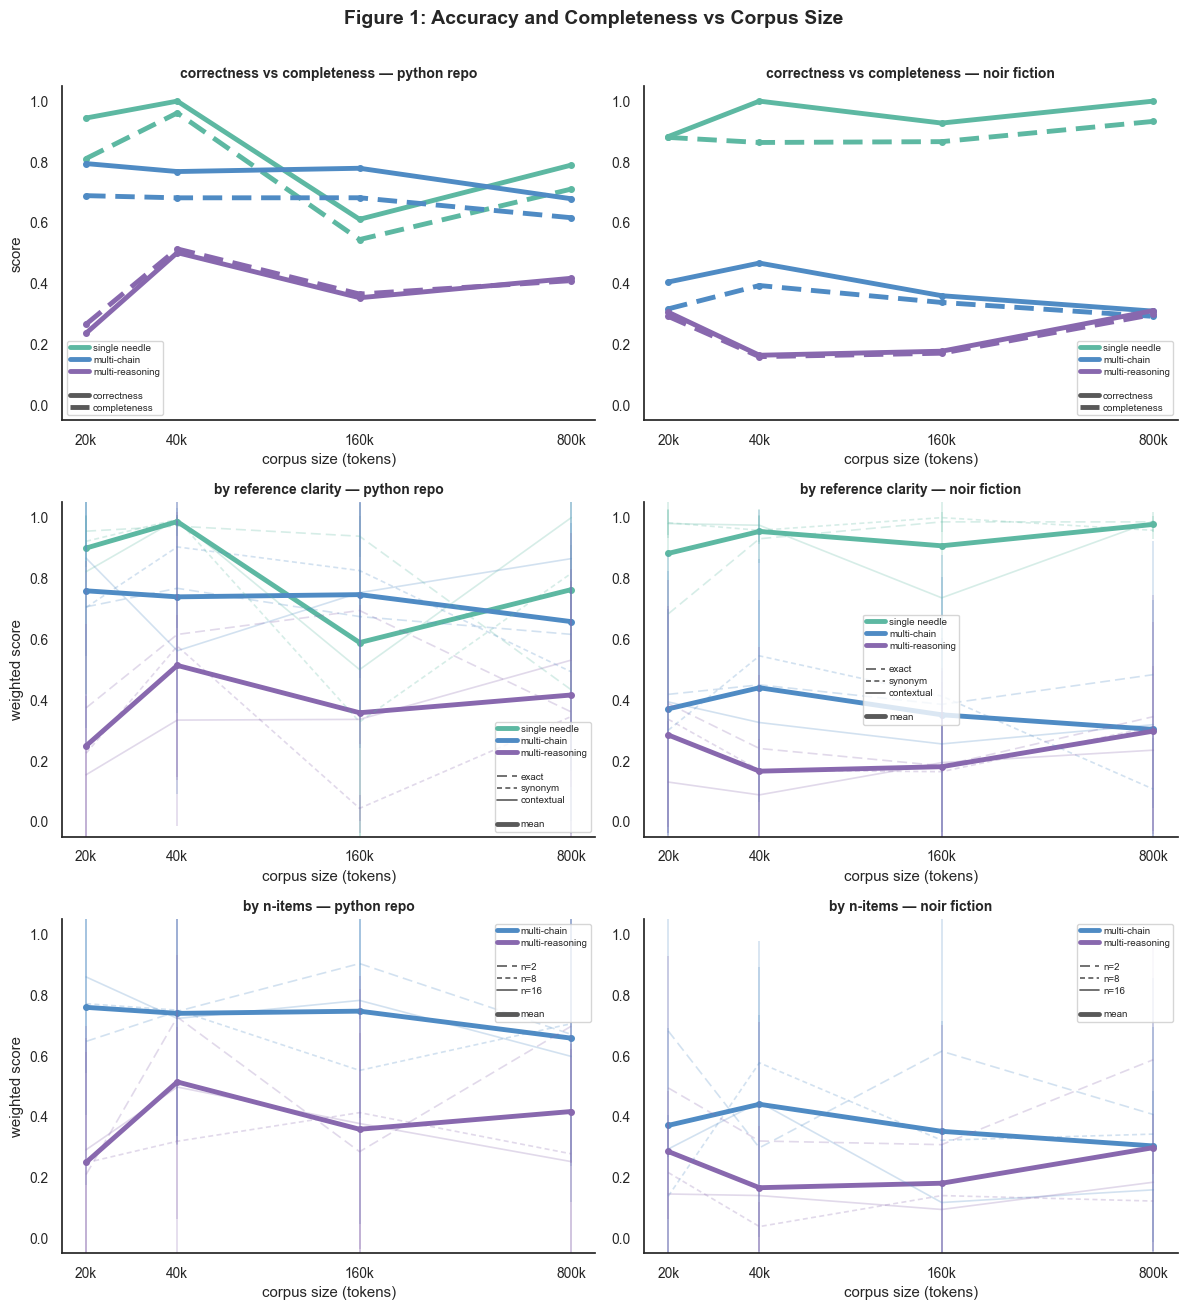

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="white", font_scale=0.9)

EXP_ORDER = ["single_needle", "multi_chain", "multi_reasoning"]
EXP_LABELS = {"single_needle": "single needle", "multi_chain": "multi-chain", "multi_reasoning": "multi-reasoning"}
PROFILES = ["python_repo", "noir_fiction"]
PROFILE_LABELS = {"noir_fiction": "noir fiction", "python_repo": "python repo"}
CLARITY_ORDER = ["exact", "synonym", "contextual"]
N_ITEMS_ORDER = [2, 8, 16]

# Cohesive teal → blue → purple (light → dark ≈ easy → hard task)
EXP_PALETTE = {"single_needle": "#5DB8A2", "multi_chain": "#4F8BC4", "multi_reasoning": "#8868AE"}

# Warm earth/amber palette for tools (distinct from cool experiment colours)
TOOL_PALETTE = ["#D4956A", "#C47858", "#B8A07A", "#9C7E68", "#BCA890"]

CLARITY_DASHES = {"exact": (6, 3), "synonym": (3, 2), "contextual": ""}
NITEMS_DASHES = {2: (6, 3), 8: (3, 2), 16: ""}

DETAIL_ALPHA = 0.25
MEAN_ALPHA = 1.0
MEAN_LW = 3.5
DETAIL_LW = 1.2

CORPUS_SIZES = [20_000, 40_000, 160_000, 800_000]
CORPUS_LABELS = ["20k", "40k", "160k", "800k"]

def set_corpus_xticks(ax):
    ax.set_xscale("log")
    ax.set_xticks(CORPUS_SIZES)
    ax.set_xticklabels(CORPUS_LABELS)
    ax.xaxis.set_minor_locator(mticker.NullLocator())

def _dash_kwargs(dash):
    """Return linestyle/dashes kwargs, avoiding passing None to matplotlib."""
    if dash:
        return {"linestyle": "--", "dashes": dash}
    return {"linestyle": "-"}

def add_legend(ax, mode="clarity"):
    type_handles = [
        mlines.Line2D([], [], color=EXP_PALETTE[e], linewidth=3.5, linestyle="-", label=EXP_LABELS[e])
        for e in EXP_ORDER if mode == "clarity" or e in ["multi_chain", "multi_reasoning"]
    ]
    spacer = mlines.Line2D([], [], linestyle="none", label="")
    if mode == "clarity":
        series_handles = [
            mlines.Line2D([], [], color="0.35", linewidth=1.2,
                          label=c, **_dash_kwargs(CLARITY_DASHES[c]))
            for c in CLARITY_ORDER
        ]
    else:
        series_handles = [
            mlines.Line2D([], [], color="0.35", linewidth=1.2,
                          label=f"n={n}", **_dash_kwargs(NITEMS_DASHES[n]))
            for n in N_ITEMS_ORDER
        ]
    mean_handle = mlines.Line2D([], [], color="0.35", linewidth=3.5, linestyle="-", label="mean")
    all_handles = type_handles + [spacer] + series_handles + [spacer, mean_handle]
    ax.legend(handles=all_handles, fontsize=7, loc="best", ncol=1,
              handletextpad=0.4, borderpad=0.3, labelspacing=0.3)

def plot_series(ax, df, y_col, exp_types, mode="clarity"):
    items = CLARITY_ORDER if mode == "clarity" else N_ITEMS_ORDER
    dashes = CLARITY_DASHES if mode == "clarity" else NITEMS_DASHES
    group_col = "reference_clarity" if mode == "clarity" else "n_items"

    for exp_type in exp_types:
        color = EXP_PALETTE[exp_type]
        sub_all = df[df["experiment_type"] == exp_type]
        if mode == "nitems":
            sub_all = sub_all.dropna(subset=["n_items"])
        if sub_all.empty:
            continue

        for item in items:
            isub = sub_all[sub_all[group_col] == item]
            if isub.empty:
                continue
            stats = isub.groupby("corpus_token_count")[y_col].agg(["mean", "std"]).reset_index()
            ax.errorbar(
                stats["corpus_token_count"], stats["mean"], yerr=stats["std"].fillna(0),
                color=color, linewidth=DETAIL_LW, capsize=0, markersize=0,
                alpha=DETAIL_ALPHA, **_dash_kwargs(dashes[item]),
            )

        mean_stats = sub_all.groupby("corpus_token_count")[y_col].agg(["mean"]).reset_index()
        ax.plot(
            mean_stats["corpus_token_count"], mean_stats["mean"],
            color=color, linewidth=MEAN_LW, alpha=MEAN_ALPHA, marker="o", markersize=4,
        )

# --- Figure 1: Accuracy and Completeness vs Corpus Size (3x2) ---
fig, axes = plt.subplots(3, 2, figsize=(12, 13))

# Row 1: correctness vs completeness (mean only, all experiment types)
SCORE_DASHES = {"correctness": "", "completeness": (4, 2)}
for col_idx, profile in enumerate(PROFILES):
    ax = axes[0, col_idx]
    sub = df[df["content_profile"] == profile]
    for exp_type in EXP_ORDER:
        color = EXP_PALETTE[exp_type]
        esub = sub[sub["experiment_type"] == exp_type]
        if esub.empty:
            continue
        for metric, dash in SCORE_DASHES.items():
            col = f"score_{metric}"
            if col not in esub.columns:
                continue
            stats = esub.dropna(subset=[col]).groupby("corpus_token_count")[col].mean().reset_index()
            ax.plot(
                stats["corpus_token_count"], stats[col],
                color=color, linewidth=MEAN_LW, alpha=MEAN_ALPHA, marker="o", markersize=4,
                **_dash_kwargs(dash),
            )
    ax.set_ylim(-0.05, 1.05)
    set_corpus_xticks(ax)
    ax.set_title(f"correctness vs completeness — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("score")
    ax.set_xlabel("corpus size (tokens)")
    type_handles = [
        mlines.Line2D([], [], color=EXP_PALETTE[e], linewidth=3.5, linestyle="-", label=EXP_LABELS[e])
        for e in EXP_ORDER
    ]
    spacer = mlines.Line2D([], [], linestyle="none", label="")
    metric_handles = [
        mlines.Line2D([], [], color="0.35", linewidth=MEAN_LW, linestyle="-", label="correctness"),
        mlines.Line2D([], [], color="0.35", linewidth=MEAN_LW, linestyle="--", dashes=(4, 2), label="completeness"),
    ]
    ax.legend(handles=type_handles + [spacer] + metric_handles, fontsize=7, loc="best",
              handletextpad=0.4, borderpad=0.3, labelspacing=0.3)
    sns.despine(ax=ax)

# Row 2: by reference clarity
for col_idx, profile in enumerate(PROFILES):
    ax = axes[1, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "weighted_score", EXP_ORDER, mode="clarity")
    ax.set_ylim(-0.05, 1.05)
    set_corpus_xticks(ax)
    ax.set_title(f"by reference clarity — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("weighted score")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="clarity")
    sns.despine(ax=ax)

# Row 3: by n-items
for col_idx, profile in enumerate(PROFILES):
    ax = axes[2, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "weighted_score", ["multi_chain", "multi_reasoning"], mode="nitems")
    ax.set_ylim(-0.05, 1.05)
    set_corpus_xticks(ax)
    ax.set_title(f"by n-items — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("weighted score")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="nitems")
    sns.despine(ax=ax)

fig.suptitle("Figure 1: Accuracy and Completeness vs Corpus Size", fontsize=14, fontweight="bold", y=1.005)
fig.tight_layout()
plt.show()

## Figure 2: Session Cost vs Corpus Size

Y-axis shows total session cost in USD as reported by the Claude Agent SDK. This includes all token costs across the full agentic session, including subagent delegations.

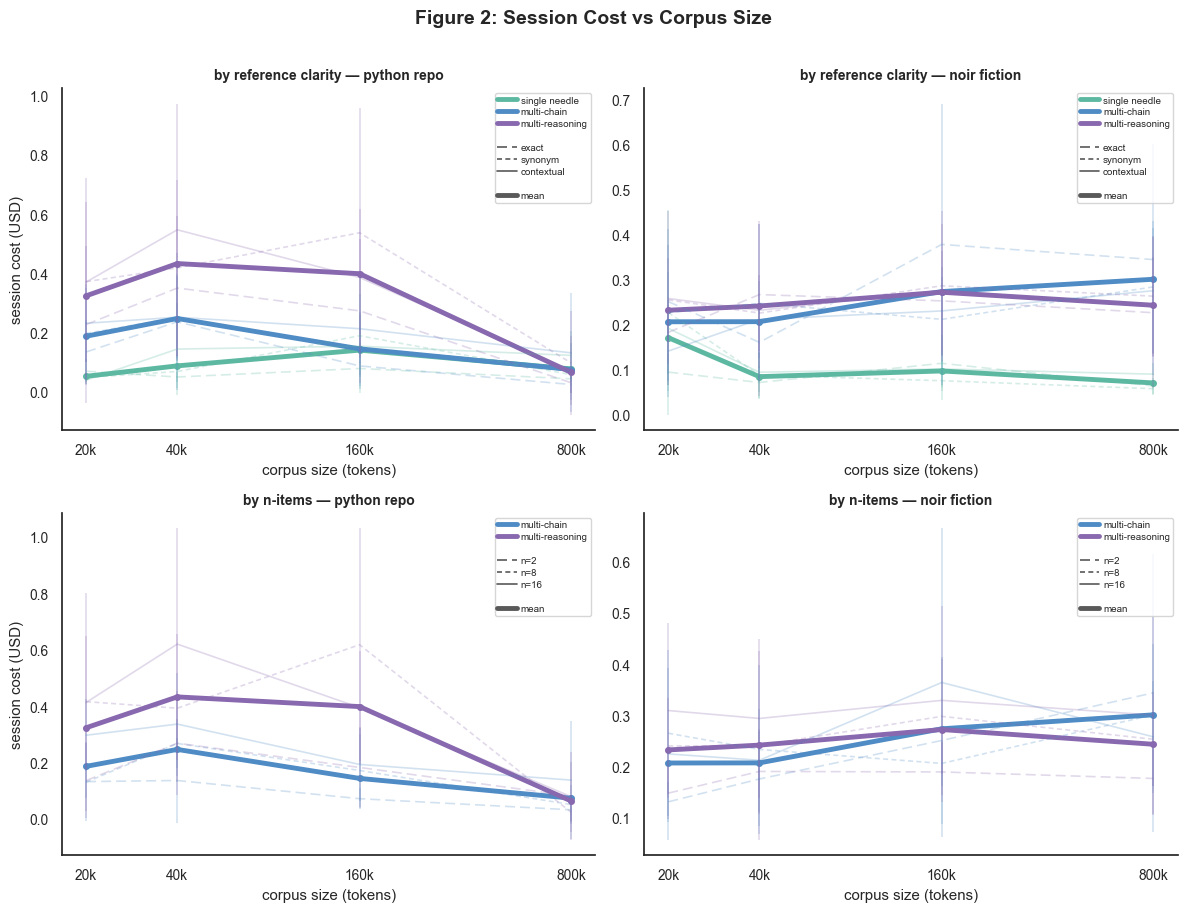

In [5]:
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 9))

# Row 1: by reference clarity
for col_idx, profile in enumerate(PROFILES):
    ax = axes2[0, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "total_cost_usd", EXP_ORDER, mode="clarity")
    set_corpus_xticks(ax)
    ax.set_title(f"by reference clarity — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("session cost (USD)")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="clarity")
    sns.despine(ax=ax)

# Row 2: by n-items
for col_idx, profile in enumerate(PROFILES):
    ax = axes2[1, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "total_cost_usd", ["multi_chain", "multi_reasoning"], mode="nitems")
    set_corpus_xticks(ax)
    ax.set_title(f"by n-items — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("session cost (USD)")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="nitems")
    sns.despine(ax=ax)

fig2.suptitle("Figure 2: Session Cost vs Corpus Size", fontsize=14, fontweight="bold", y=1.01)
fig2.tight_layout()
plt.show()

## Figure 3: Tool Calls vs Corpus Size

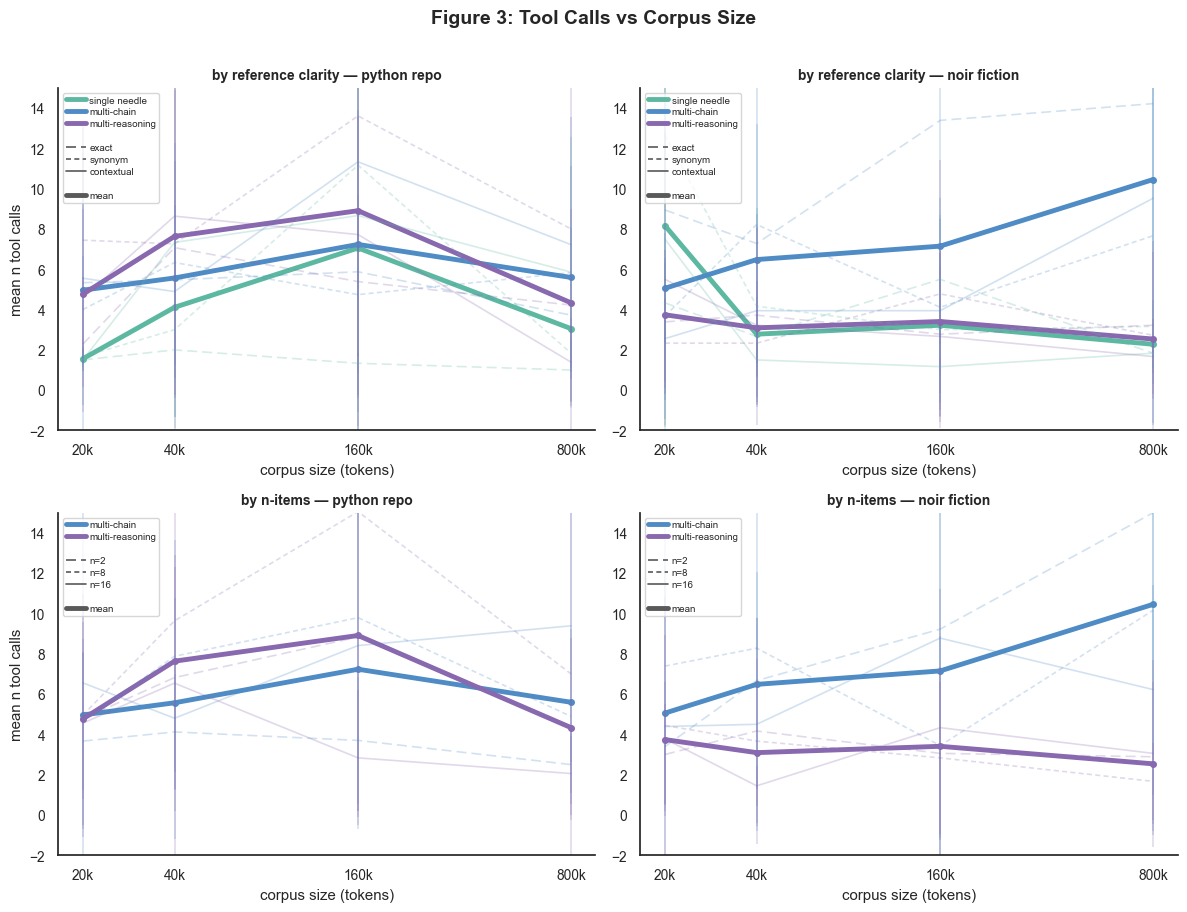

In [6]:
tool_cols = [c for c in df.columns if c.startswith("tool_")]
df["total_tool_calls"] = df[tool_cols].sum(axis=1)

max_tool_mean = df.groupby(["experiment_type", "corpus_token_count"])["total_tool_calls"].mean().max()
tool_ylim = (-2, int(np.ceil(max_tool_mean / 5) * 5) + 5)

fig3, axes3 = plt.subplots(2, 2, figsize=(12, 9))

# Row 1: by reference clarity
for col_idx, profile in enumerate(PROFILES):
    ax = axes3[0, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "total_tool_calls", EXP_ORDER, mode="clarity")
    set_corpus_xticks(ax)
    ax.set_ylim(tool_ylim)
    ax.set_title(f"by reference clarity — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("mean n tool calls")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="clarity")
    sns.despine(ax=ax)

# Row 2: by n-items
for col_idx, profile in enumerate(PROFILES):
    ax = axes3[1, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "total_tool_calls", ["multi_chain", "multi_reasoning"], mode="nitems")
    set_corpus_xticks(ax)
    ax.set_ylim(tool_ylim)
    ax.set_title(f"by n-items — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("mean n tool calls")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="nitems")
    sns.despine(ax=ax)

fig3.suptitle("Figure 3: Tool Calls vs Corpus Size", fontsize=14, fontweight="bold", y=1.01)
fig3.tight_layout()
plt.show()

## Figure 4: Tool Breakdown by Experiment Type

/var/folders/zv/0hhdfq397mz_9z3sswdh9bq80000gn/T/ipykernel_50607/2722937695.py:22: UserWarning: 
The palette list has fewer values (5) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


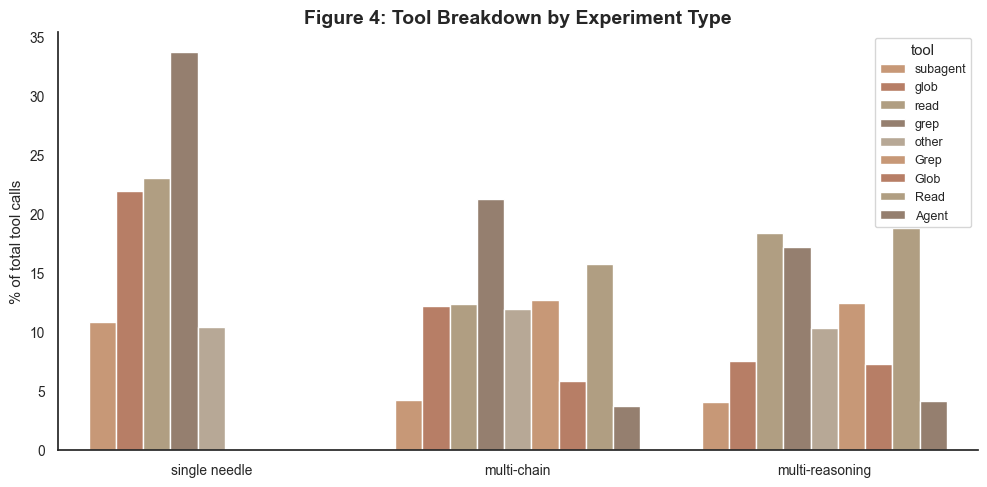

In [7]:
import pandas as pd

tool_cols = [c for c in df.columns if c.startswith("tool_")]
tool_names = [c.replace("tool_", "") for c in tool_cols]

tool_data = []
for exp_type in EXP_ORDER:
    sub = df[df["experiment_type"] == exp_type]
    means = {tn: sub[tc].mean() for tc, tn in zip(tool_cols, tool_names) if not np.isnan(sub[tc].mean())}
    total = sum(means.values())
    if total > 0:
        for tn, mean_val in means.items():
            tool_data.append({
                "experiment type": EXP_LABELS[exp_type],
                "tool": tn,
                "% of total calls": mean_val / total * 100,
            })

tool_df = pd.DataFrame(tool_data)

fig4, ax4 = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=tool_df, x="experiment type", y="% of total calls", hue="tool",
    palette=TOOL_PALETTE, ax=ax4,
)
ax4.set_title("Figure 4: Tool Breakdown by Experiment Type", fontsize=14, fontweight="bold")
ax4.legend(title="tool", fontsize=9)
ax4.set_xlabel("")
ax4.set_ylabel("% of total tool calls")
sns.despine(ax=ax4)
fig4.tight_layout()
plt.show()

## V2 Parameter Breakdowns

In [8]:
from agent_retrieval.analysis.tables import accuracy_by_param

print("=== By Discriminability ===")
display(accuracy_by_param(df, "discriminability"))

print("\n=== By Reference Clarity ===")
display(accuracy_by_param(df, "reference_clarity"))

print("\n=== By Content Profile ===")
display(accuracy_by_param(df, "content_profile"))

print("\n=== By N Items ===")
display(accuracy_by_param(df, "n_items"))

=== By Discriminability ===


,experiment_type,discriminability,mean,std,count
0,multi_chain,easy,0.593034,0.452385,245
1,multi_chain,hard,0.540018,0.450304,240
2,multi_reasoning,easy,0.321167,0.397708,221
3,multi_reasoning,hard,0.306618,0.389705,223
4,single_needle,easy,0.883565,0.300464,72
5,single_needle,hard,0.855482,0.286180,73



=== By Reference Clarity ===


,experiment_type,reference_clarity,mean,std,count
0,multi_chain,contextual,0.553910,0.454545,164
1,multi_chain,exact,0.573830,0.440932,159
2,multi_chain,synonym,0.572948,0.461576,162
3,multi_reasoning,contextual,0.251772,0.328409,149
4,multi_reasoning,exact,0.412925,0.444107,153
5,multi_reasoning,synonym,0.272269,0.379190,142
6,single_needle,contextual,0.877212,0.302529,49
7,single_needle,exact,0.860765,0.279997,48
8,single_needle,synonym,0.870142,0.300731,48



=== By Content Profile ===


,experiment_type,content_profile,mean,std,count
0,multi_chain,noir_fiction,0.366072,0.415380,217
1,multi_chain,python_repo,0.729329,0.413478,268
2,multi_reasoning,noir_fiction,0.232139,0.324311,216
3,multi_reasoning,python_repo,0.391279,0.435810,228
4,single_needle,noir_fiction,0.930557,0.180158,72
5,single_needle,python_repo,0.809134,0.363170,73



=== By N Items ===


,experiment_type,n_items,mean,std,count
0,multi_chain,2.0,0.647018,0.437009,163
1,multi_chain,8.0,0.529259,0.454809,162
2,multi_chain,16.0,0.523086,0.454983,160
3,multi_reasoning,2.0,0.460653,0.441562,148
4,multi_reasoning,8.0,0.223108,0.333282,146
5,multi_reasoning,16.0,0.257355,0.356137,150


## Custom Analysis
Use the `results` DataFrame for ad-hoc exploration.

In [9]:
df.describe()

,weighted_score,total_context_tokens,total_turns,duration_seconds,total_cost_usd,corpus_token_count,n_items,tool_subagent,tool_glob,score_correctness,...,score_multi_source_synthesis,score_identification_of_all_eight_items,score_correct_timeline_construction,score_understanding_of_compartmentalization,score_evidence_synthesis_across_sources,score_causal_reasoning_about_parallel_operations,score_integration_understanding,score_cross_file_reasoning,score_constraint_identification,total_tool_calls
count,1074.000000,1.074000e+03,1074.000000,1074.0,1074.000000,1074.000000,929.000000,403.000000,247.000000,1062.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000,1074.000000
mean,0.503090,1.641559e+05,7.446927,0.0,0.221726,244636.871508,8.660926,1.176179,3.000000,0.519981,...,0.416667,0.066667,0.066667,0.166667,0.050000,0.100000,0.666667,0.226667,0.400,5.534451
std,0.449642,2.640959e+05,9.000957,0.0,0.208506,311616.218516,5.745143,0.424649,2.719995,0.468013,...,0.152753,0.115470,0.115470,0.288675,0.086603,0.173205,0.076376,0.040415,0.350,7.372857
min,0.000000,1.725900e+04,1.000000,0.0,0.000000,20000.000000,2.000000,1.000000,1.000000,0.000000,...,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.600000,0.180000,0.000,0.000000
25%,0.000000,3.695375e+04,2.000000,0.0,0.077588,40000.000000,2.000000,1.000000,1.000000,0.000000,...,0.350000,0.000000,0.000000,0.000000,0.000000,0.000000,0.625000,0.215000,0.275,1.000000
50%,0.552650,5.460850e+04,3.000000,0.0,0.175176,40000.000000,8.000000,1.000000,2.000000,0.610000,...,0.450000,0.000000,0.000000,0.000000,0.000000,0.000000,0.650000,0.250000,0.550,2.000000
75%,1.000000,1.561012e+05,9.000000,0.0,0.288189,160000.000000,16.000000,1.000000,4.000000,1.000000,...,0.500000,0.100000,0.100000,0.250000,0.075000,0.150000,0.700000,0.250000,0.600,7.000000
max,1.000000,2.634567e+06,72.000000,0.0,1.637386,800000.000000,16.000000,4.000000,22.000000,1.000000,...,0.550000,0.200000,0.200000,0.500000,0.150000,0.300000,0.750000,0.250000,0.650,55.000000
